# Ejemplo resuelto — Clustering de canciones (Spotify)

Este notebook es un **ejemplo terminado** para que veas la forma del trabajo: el mismo flujo de cinco etapas que tu práctica, aplicado a otro problema. Mirá cómo cada gráfico viene con su lectura y cada decisión con su porqué — eso es lo que se espera de tu análisis.

**El caso:** trabajás en el equipo de playlists editoriales de **Spotify**. Te pasan un catálogo de 410 canciones nuevas y te piden armar playlists: ¿cuántas hacen falta y de qué tipo? Nadie etiquetó las canciones por género — solo tenés sus características de audio.

**Con qué contás:** `canciones_spotify.csv` — energía, bailabilidad, acústica, duración y popularidad de cada canción.

## 1. El negocio

- **El problema:** hay 410 canciones sin clasificar y el equipo editorial no puede escucharlas una por una.
- **La pregunta a los datos:** ¿qué grupos de canciones parecidas hay en el catálogo?
- **¿Supervisado o no supervisado?** No supervisado: nadie nos dio la etiqueta "género" — la estructura hay que descubrirla.
- **La decisión:** qué playlists lanzar, y cuál promocionar primero.

## 2. Los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('canciones_spotify.csv')
df.head()

,cancion,artista,energia,bailabilidad,acustica,duracion_seg,popularidad
0,Motor en Vivo,Reina Mota,60.0,42.0,37.0,351.0,71.0
1,Neón Eterno,Kraft B,90.0,61.0,5.0,375.0,30.0
2,Ritmo 2.0,Los del Sur,82.0,85.0,14.0,209.0,75.0
3,Fuego Azul,Los del Sur,76.0,95.0,0.0,197.0,74.0
4,Salto Azul,Kraft B,92.0,53.0,4.0,329.0,35.0


In [2]:
print(df.shape)
df.describe().round(0)

(410, 7)


,energia,bailabilidad,acustica,duracion_seg,popularidad
count,410.0,410.0,410.0,410.0,410.0
mean,68.0,57.0,30.0,262.0,58.0
std,26.0,23.0,32.0,69.0,19.0
min,8.0,19.0,0.0,163.0,13.0
25%,57.0,39.0,5.0,204.0,44.0
50%,78.0,50.0,14.0,246.0,58.0
75%,89.0,85.0,40.0,320.0,73.0
max,100.0,99.0,100.0,421.0,96.0


**Lectura.** 410 canciones, 5 variables numéricas, sin datos faltantes. Las escalas son distintas: energía/bailabilidad/acústica/popularidad van de 0 a 100, pero la duración va de ~130 a ~440 segundos. Anotamos eso para la preparación.

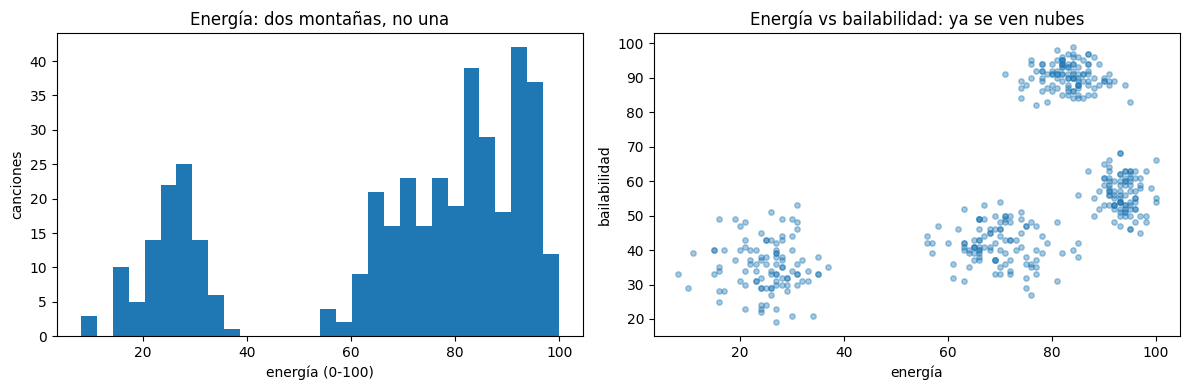

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma: ¿cómo se distribuye la energía del catálogo?
axes[0].hist(df['energia'], bins=30)
axes[0].set_title('Energía: dos montañas, no una')
axes[0].set_xlabel('energía (0-100)')
axes[0].set_ylabel('canciones')

# Scatter: ¿energía y bailabilidad juntas insinúan grupos?
axes[1].scatter(df['energia'], df['bailabilidad'], alpha=0.4, s=15)
axes[1].set_title('Energía vs bailabilidad: ya se ven nubes')
axes[1].set_xlabel('energía')
axes[1].set_ylabel('bailabilidad')
plt.tight_layout()
plt.show()

**Lectura.** El histograma de energía NO tiene una sola montaña: hay un grupo de canciones calmas y otro de canciones intensas — primera evidencia de que el catálogo no es homogéneo. Y el scatter muestra nubes separadas: hay estructura esperando que la encontremos. Todavía no sabemos cuántos grupos son.

## 3. Preparación

Dos decisiones, cada una con su porqué:

- **Qué columnas entran:** las 5 numéricas de audio. Afuera `cancion` y `artista`: son texto identificatorio, no describen cómo suena la canción.
- **Estandarizar:** obligatorio. K-Means mide distancias, y la duración (hasta 440) aplastaría a las variables de 0-100. Después de estandarizar, todas pesan igual.

In [4]:
from sklearn.preprocessing import StandardScaler

features = ['energia', 'bailabilidad', 'acustica', 'duracion_seg', 'popularidad']
X = StandardScaler().fit_transform(df[features])
print("matriz lista para el modelo:", X.shape)

matriz lista para el modelo: (410, 5)


## 4. El modelo — K-Means

¿Cuántos grupos? Corremos K-Means para varios k y dejamos que el codo y Silhouette nos orienten.

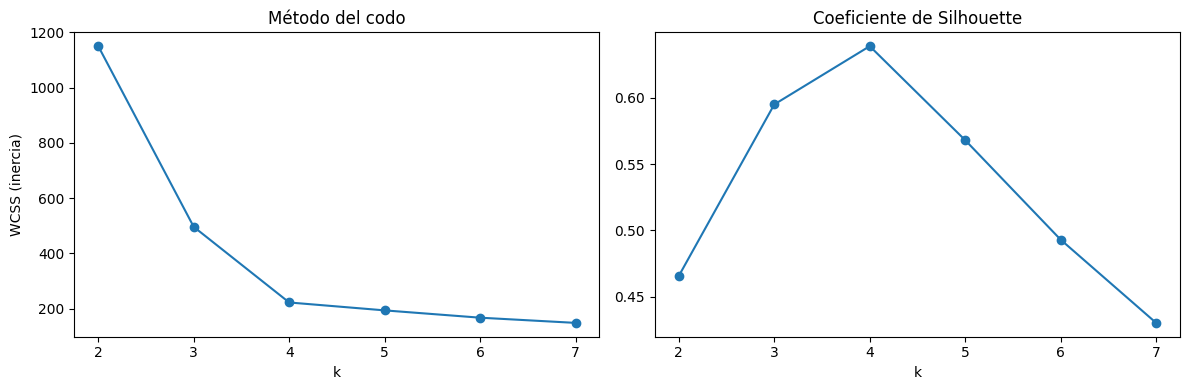

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 8)
inercias, siluetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inercias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS (inercia)')
axes[1].plot(list(ks), siluetas, marker='o')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

**Lectura.** Acá las dos métricas dicen lo mismo: el codo se quiebra en k=4 (la inercia baja de 1.150 a 222 y después gotea) y Silhouette es máximo en k=4 (0,64). Cuando los grupos son nítidos, las métricas se ponen de acuerdo. **Aviso: no siempre pasa** — con datos reales suelen contradecirse, y ahí desempata el negocio.

In [6]:
K = 4
modelo = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
df['cluster'] = modelo.labels_
df['cluster'].value_counts().sort_index()

cluster
0    100
1     94
2    110
3    106
Name: count, dtype: int64

## 5. Evaluación y decisión

Etiquetas puestas. Ahora: ¿quiénes son estos grupos y qué hacemos con ellos?

In [7]:
perfil = df.groupby('cluster')[features].mean().round(0)
perfil['canciones'] = df['cluster'].value_counts().sort_index()
perfil

,energia,bailabilidad,acustica,duracion_seg,popularidad,canciones
cluster,,,,,,
0,25.0,35.0,84.0,228.0,50.0,100
1,94.0,56.0,3.0,364.0,36.0,94
2,83.0,91.0,8.0,189.0,77.0,110
3,70.0,42.0,26.0,280.0,64.0,106


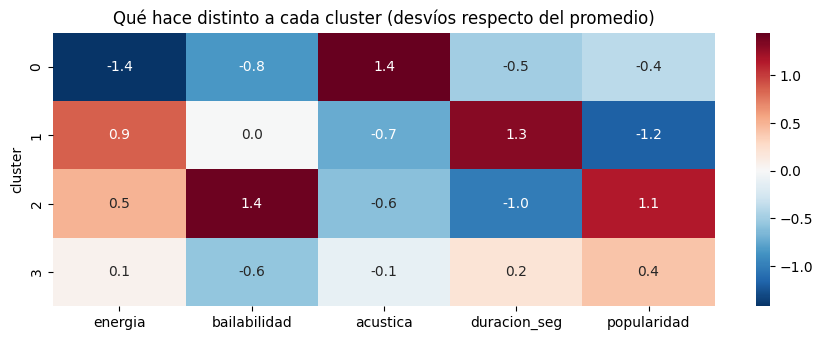

In [8]:
# Heatmap: el perfil de cada grupo en un golpe de vista
perfil_norm = (perfil[features] - perfil[features].mean()) / perfil[features].std()
plt.figure(figsize=(9, 3.5))
sns.heatmap(perfil_norm, annot=True, fmt='.1f', cmap='RdBu_r', center=0)
plt.title('Qué hace distinto a cada cluster (desvíos respecto del promedio)')
plt.tight_layout()
plt.show()

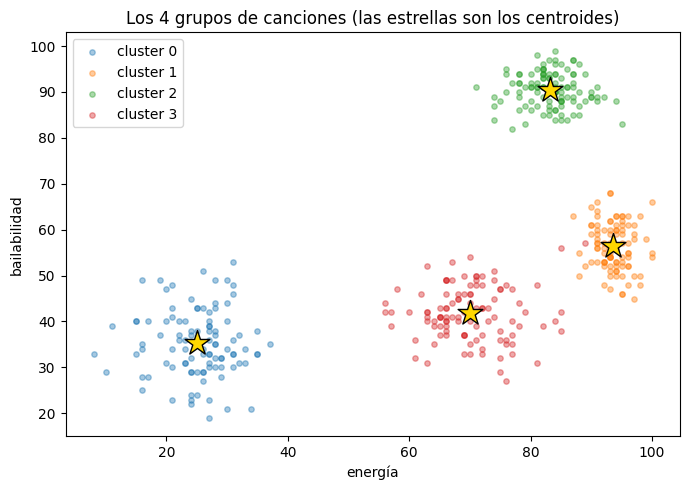

In [9]:
# Los grupos en el plano que el equipo editorial entiende, con su centroide
plt.figure(figsize=(7, 5))
for c in sorted(df['cluster'].unique()):
    g = df[df['cluster'] == c]
    plt.scatter(g['energia'], g['bailabilidad'], alpha=0.4, s=15, label=f'cluster {c}')
    plt.scatter(g['energia'].mean(), g['bailabilidad'].mean(),
                marker='*', s=350, color='gold', edgecolor='black', zorder=5)
plt.xlabel('energía')
plt.ylabel('bailabilidad')
plt.legend()
plt.title('Los 4 grupos de canciones (las estrellas son los centroides)')
plt.tight_layout()
plt.show()

**Los grupos, bautizados leyendo la tabla** (el algoritmo da números; el nombre lo pone el analista):

- **Cluster 0 — "Café Acústico" (100 canciones):** energía 25, acústica 84. Calmas, orgánicas, de duración media.
- **Cluster 1 — "Modo Entrenamiento" (94):** energía 94, acústica 3, duración 364 segundos — temas larguísimos e intensos. Popularidad baja (36): nicho.
- **Cluster 2 — "Modo Fiesta" (110):** bailabilidad 91, cortas (189 seg) y las más populares del catálogo (77).
- **Cluster 3 — "Rock de Ruta" (106):** energía alta (70) pero poco bailables (42), largas, populares (64).

**La decisión para el equipo editorial:**

- Lanzamos las **4 playlists** — cada grupo tiene tamaño suficiente (94 a 110 canciones).
- **Promocionamos primero "Modo Fiesta":** es el grupo más grande y el de mayor popularidad promedio — la apuesta más segura para la home.
- **"Modo Entrenamiento" se lanza sin promoción:** popularidad 36 — es contenido de nicho; gastarle promoción masiva sería repetir el error de tratar a todo el catálogo igual.
- **¿Funcionó?** En un mes miramos saves y skips por playlist: si "Modo Fiesta" no retiene, el nombre o la selección están mal — los clusters solo agrupan, la propuesta editorial la hicimos nosotros.

**Ahora te toca a vos:** tu práctica sigue este mismo flujo, con otro negocio y más decisiones tuyas en el camino. Mismo esqueleto, criterio propio.